## Desafio Algoritmos Supervisionados / Regressão Linear - Módulo 5

In [44]:
# pipenv install scikit-learn scipy pandas matplotlib statsmodels fastapi uvicorn pingouin seaborn ipykernel

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Carregar os dados de irrigação a partir de um arquivo CSV

In [3]:
# Abrir o dataset
df_irrigacao = pd.read_csv('./datasets/dados_de_irrigacao.csv')

### Visualizar os dados para entender a estrutura e as variáveis disponíveis

In [4]:
# Checagem de estrutura do Dataset
df_irrigacao.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Horas de Irrigação        299 non-null    int64  
 1   Área Irrigada             299 non-null    int64  
 2   Área Irrigada por Ângulo  299 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 7.1 KB


In [5]:
# Visualizar topo do DF
df_irrigacao.head(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333
5,6,600,400.000000
6,7,700,466.666667
7,8,800,533.333333
8,9,900,600.000000
9,10,1000,666.666667


In [6]:
# Visualizar fim do DF
df_irrigacao.tail(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
289,290,29000,19333.333333
290,291,29100,19400.000000
291,292,29200,19466.666667
292,293,29300,19533.333333
293,294,29400,19600.000000
294,295,29500,19666.666667
295,296,29600,19733.333333
296,297,29700,19800.000000
297,298,29800,19866.666667
298,299,29900,19933.333333


### Calcular as estatísticas descritivas das variáveis

In [7]:
# Medidas estatísticas das variáveis
df_irrigacao.describe()

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
count,299.000000,299.000000,299.000000
mean,150.000000,15000.000000,10000.000000
std,86.458082,8645.808233,5763.872155
min,1.000000,100.000000,66.666667
25%,75.500000,7550.000000,5033.333333
50%,150.000000,15000.000000,10000.000000
75%,224.500000,22450.000000,14966.666667
max,299.000000,29900.000000,19933.333333


### Criar gráficos de dispersão para visualizar a relação entre horas de irrigação e área irrigada por ângulo

<Axes: xlabel='Horas de Irrigação', ylabel='Área Irrigada por Ângulo'>

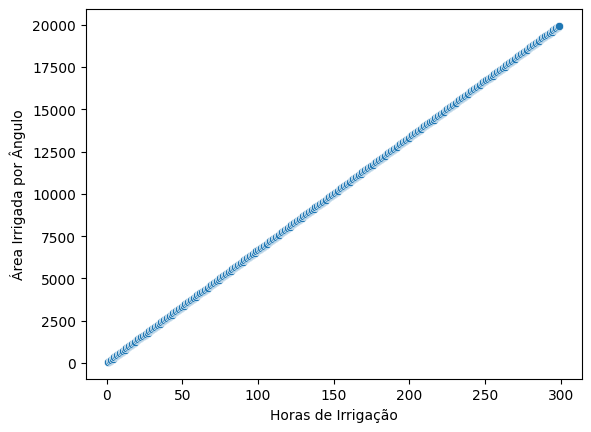

In [8]:
# Plot de Dispersão
# X = 'Horas de Irrigação'
# Y = 'Área Irrigada por Ângulo'
sns.scatterplot(data=df_irrigacao, x='Horas de Irrigação', y='Área Irrigada por Ângulo')

Indicativo de forte relação linear aparente

<Axes: ylabel='Horas de Irrigação'>

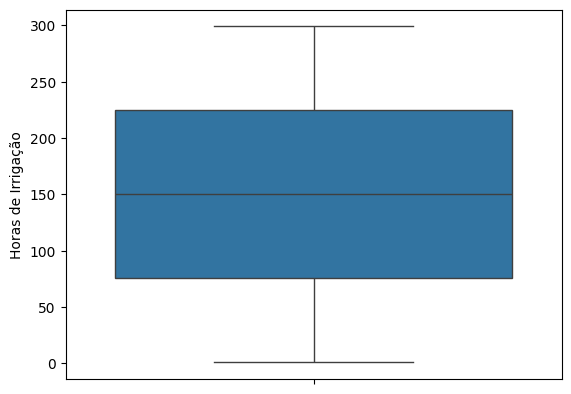

In [10]:
# Verificar se existem outliers - 'Horas de Irrigação'
# Plot BoxPlot
sns.boxplot(df_irrigacao, y='Horas de Irrigação')

Sem outliers para 'Horas de Irrigação'

<Axes: ylabel='Área Irrigada por Ângulo'>

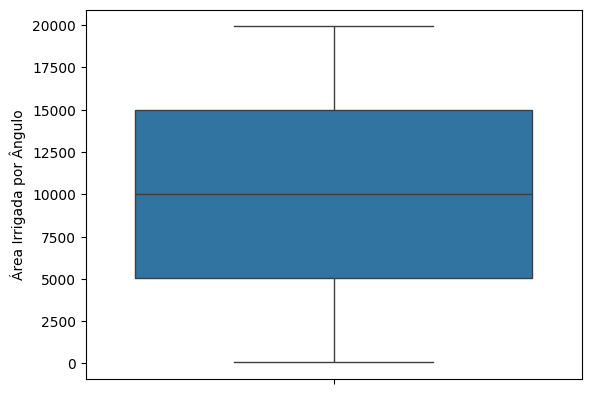

In [9]:
# Verificar se existem outliers - 'Área Irrigada por Ângulo'
# Plot BoxPlot
sns.boxplot(df_irrigacao, y='Área Irrigada por Ângulo')

Sem outliers para 'Área Irrigada por Ângulo'

### Analisar a correlação entre as variáveis

<Axes: >

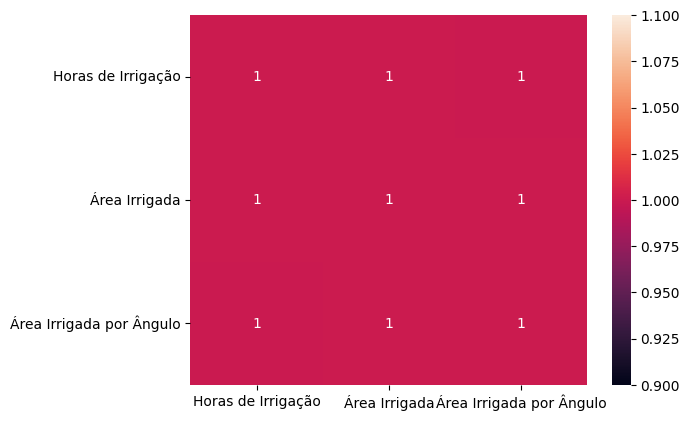

In [12]:
# Verificar Correlação - Pearson
sns.heatmap(df_irrigacao.corr('pearson'), annot = True)

<Axes: >

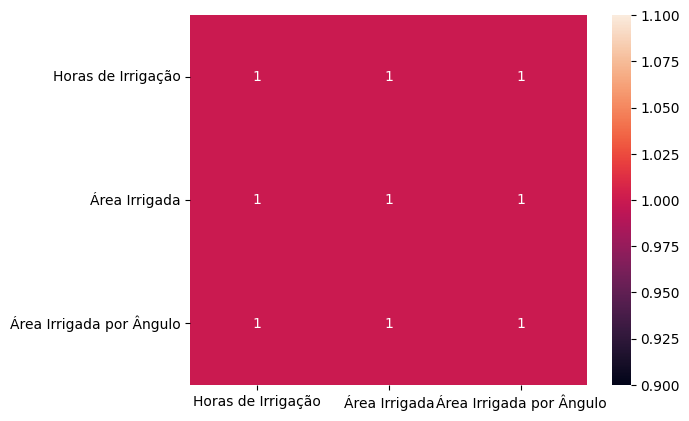

In [13]:
# Verificar Correlação - Spearman
sns.heatmap(df_irrigacao.corr('spearman'), annot = True)

Verifica-se uma forte correlação entre as 3 variáveis

### Dividir os dados em conjuntos de treino e teste

In [20]:
# Dividir dataset entre treino e teste
X = df_irrigacao['Horas de Irrigação'].values.reshape(-1, 1)
y = df_irrigacao['Área Irrigada por Ângulo'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=50)

### Treinar um modelo de regressão linear utilizando 'horas de irrigação' como variável independente (X) e 'área irrigada por ângulo' como variável dependente (Y)

In [21]:
# Instanciar o modelo a ser treinado 
reg_model = LinearRegression()

In [22]:
# Treinar o modelo
reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Imprimir a equação da reta obtida pelo modelo

In [23]:
# Imprimir a equação da reta
# y = aX + b
print("A equação da reta obtida é y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

A equação da reta obtida é y = 66.666667x + 0.000000


Assim, equação da reta é y = 66.666667x

### Utilizar as métricas de desempenho (MSE, MAE) para avaliar a precisão do modelo

In [24]:
# Predição dos valores com base no conjunto de testes
y_pred = reg_model.predict(X_test)

In [25]:
# Importar bibliotecas
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
# Calcular métrica MAE (Mean Absolute Error)
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar
# É menos sensível a outliers
mean_absolute_error(y_test, y_pred)

1.8764644159495625e-12

In [27]:
# Calcular métrica MSE (Mean Squared Error)
# MSE = Média (y_test - y_pred)2
# Não é uma métrica fácil de interpretar
# É mais sensível a outliers e penaliza grandes erros
mean_squared_error(y_test, y_pred)

5.0788674199138044e-24

Observa-se valores muito pequenos, na casa de 10^-12 e 10^-24

### Visualizar os resultados reais e preditos em um gráfico

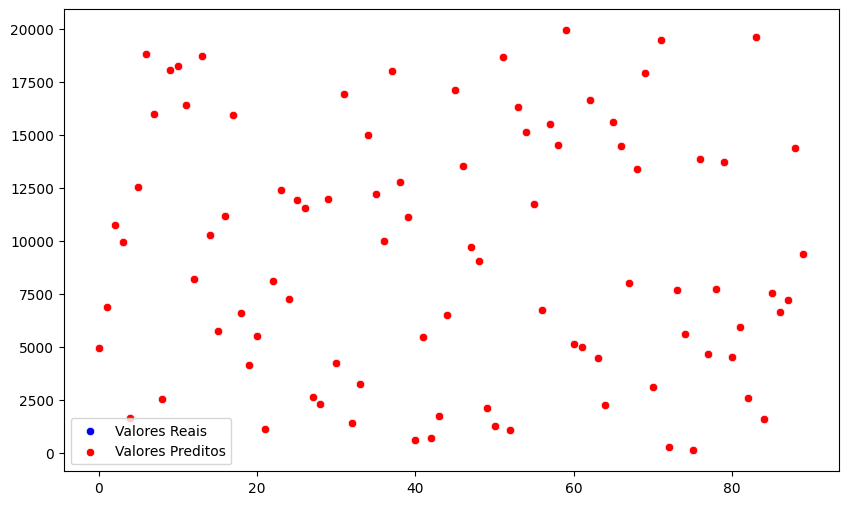

In [31]:
# Análise Gráfica - Resultados Reais X Preditos
x_axis = range(len(y_test))
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores Preditos')
plt.legend()
plt.show()

Os pontos azuis não são observados, pois estão "abaixo" dos pontos vermelhos, o que indica ótimas predições em relação aos valores reais.

### Calcular e analisar os resíduos do modelo

In [34]:
# Calcular resíduos
residuos = y_test - y_pred

In [35]:
# Calcular os resíduos padrdonizados (standardization)
# P/ c/ elemento de um conjunto: (X - media) / desvio_padrao
from scipy.stats import zscore
residuos_std = zscore(residuos)

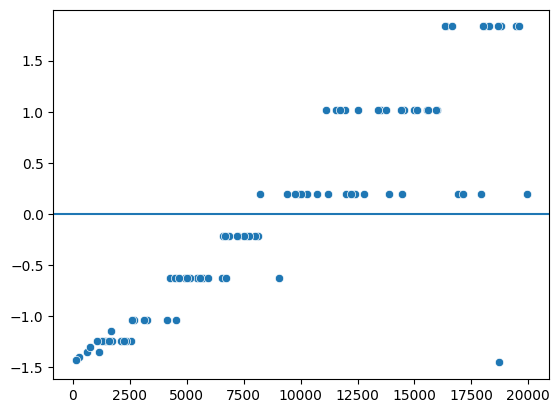

In [36]:
# Verificar linearidade do modelo:
# Se os resíduos estiverem entre -2 e +2 (na escala padrão) - indica linearidade

# Verificar homogeneidade das variâncias (Homocedasticidade)
# Valores estiverem em torno da reta, temos homocedasticidade, caso contrário,
# se tivermos alguma tendência ou padrão (formam um cone, funil), há heterocedasticidade

sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1))
plt.axhline(y=0)

Indicativo de homocedasticidade.

### Verificar a normalidade dos resíduos utilizando testes estatísticos e gráficos

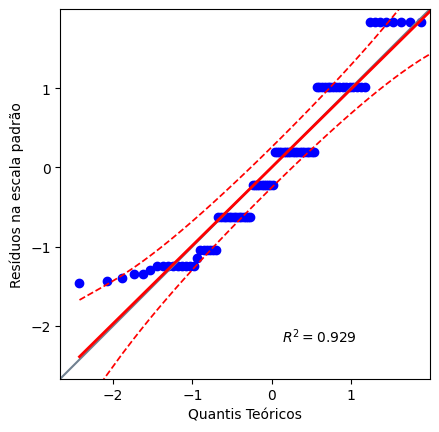

In [37]:
# Checar se resíduos seguem uma distribuição normal
# QQ (Quantile-Quantile) Plot, que avalia se uma amostra segue uma distribuição normal

import pingouin as pg
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teóricos')
plt.ylabel('Resíduos na escala padrão')
plt.show()

In [38]:
# Teste de Normalidade - Shapiro Wilk
# H0 - Segue distribuição normal
# H1 - Não segue distribuição normal
# Se o p-valor > 0.05 não rejeita H0, caso contrário, rejeita
stat_shapiro, p_valor_shapiro = shapiro(residuos.reshape(-1))
print("Estatística do teste: {} e P-Valor: {}".format(stat_shapiro, p_valor_shapiro))

Estatística do teste: 0.9188782351154261 e P-Valor: 3.150814299065697e-05


P-valor < 0.05, ou seja, rejeita H0 (não segue distribuição normal).

In [39]:
# Teste de Normalidade - Kolmogorov-Smirnov
# H0 - Segue distribuição normal
# H1 - Não segue distribuição normal
# Se o p-valor > 0.05 não rejeita H0, caso contrário, rejeita
stat_ks, p_valor_ks = kstest(residuos.reshape(-1), 'norm')
print("Estatística do teste: {} e P-Valor: {}".format(stat_ks, p_valor_ks))

Estatística do teste: 0.49999999999854866 e P-Valor: 2.4869515023142266e-21


P-valor < 0.05, ou seja, rejeita H0 (não segue distribuição normal).

### Utilizar modelo para fazer perdições (exemplo: prever área irrigada por ângulo para 15 horas de irrigação)

In [42]:
# Se eu irrigar por 15 horas, 
# qual a área irrigada por ângulo prevista pelo modelo?
reg_model.predict([[15]])

array([[1000.]])

In [43]:
# Quantas horas irrigar para obter 
# 1000 de área irrigada por ângulo (pelo modelo)?
# y = aX + b 
# x = (y - b) / a
(1000 - reg_model.intercept_[0]) / reg_model.coef_[0][0]

np.float64(14.99999999999995)

Observa-se um valor muito próximo de 15 horas realmente, conforme predição anterior.